<a href="https://colab.research.google.com/github/celalthedon/cnn-experiments/blob/main/transfer_learning_image_classification_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as T
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)

In [ ]:
!wget https://github.com/jordan-bird/CIFAKE-Real-and-AI-Generated-Synthetic-Images/archive/refs/heads/main.zip

--2026-04-21 17:04:00--  https://github.com/jordan-bird/CIFAKE-Real-and-AI-Generated-Synthetic-Images/archive/refs/heads/main.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/jordan-bird/CIFAKE-Real-and-AI-Generated-Synthetic-Images/zip/refs/heads/main [following]
--2026-04-21 17:04:00--  https://codeload.github.com/jordan-bird/CIFAKE-Real-and-AI-Generated-Synthetic-Images/zip/refs/heads/main
Resolving codeload.github.com (codeload.github.com)... 140.82.116.10
Connecting to codeload.github.com (codeload.github.com)|140.82.116.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘main.zip.1’

main.zip.1              [    <=>             ] 115.54M  17.1MB/s    in 7.6s    

2026-04-21 17:04:08 (15.2 MB/s) - ‘main.zip.1’ saved [121148911]



In [ ]:
from zipfile import ZipFile
with ZipFile('main.zip', 'r') as f:
    f.extractall()

In [ ]:
from torchvision import datasets, transforms
from pathlib import Path

DATA_PATH = Path("/content/CIFAKE-Real-and-AI-Generated-Synthetic-Images-main/DATASET")

In [ ]:
for split in ["train", "test"]:
    for cls in ["FAKE", "REAL"]:
        folder = DATA_PATH / split / cls
        count = len(list(folder.glob("*")))
        print(f"{split}/{cls}: {count}")

train/FAKE: 50000
train/REAL: 50000
test/FAKE: 10000
test/REAL: 10000


In [ ]:
summary ={}

for split in ["train", "test"]:
    summary[split] = {}

    for cls in ["FAKE", "REAL"]:
        folder = DATA_PATH / split / cls
        count = len(list(folder.glob("*")))

        summary[split][cls] = count

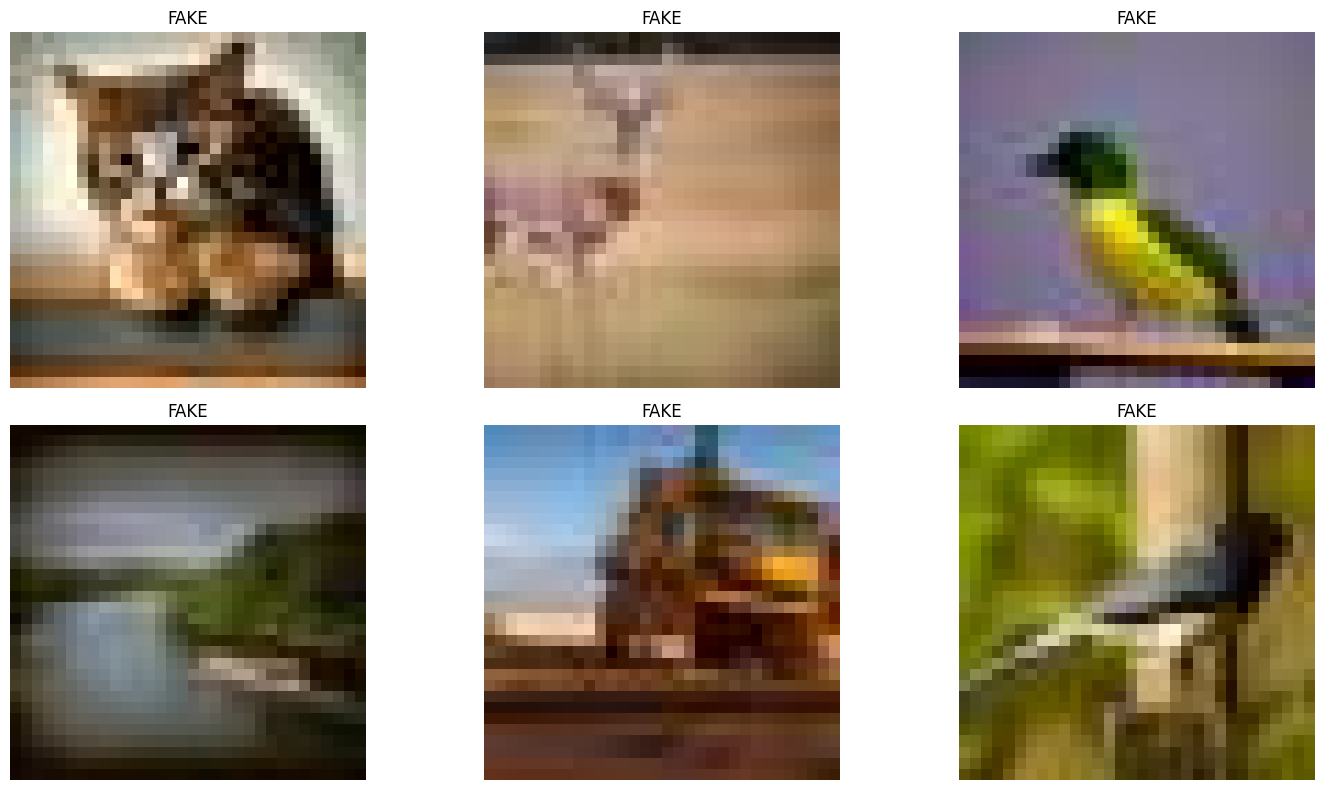

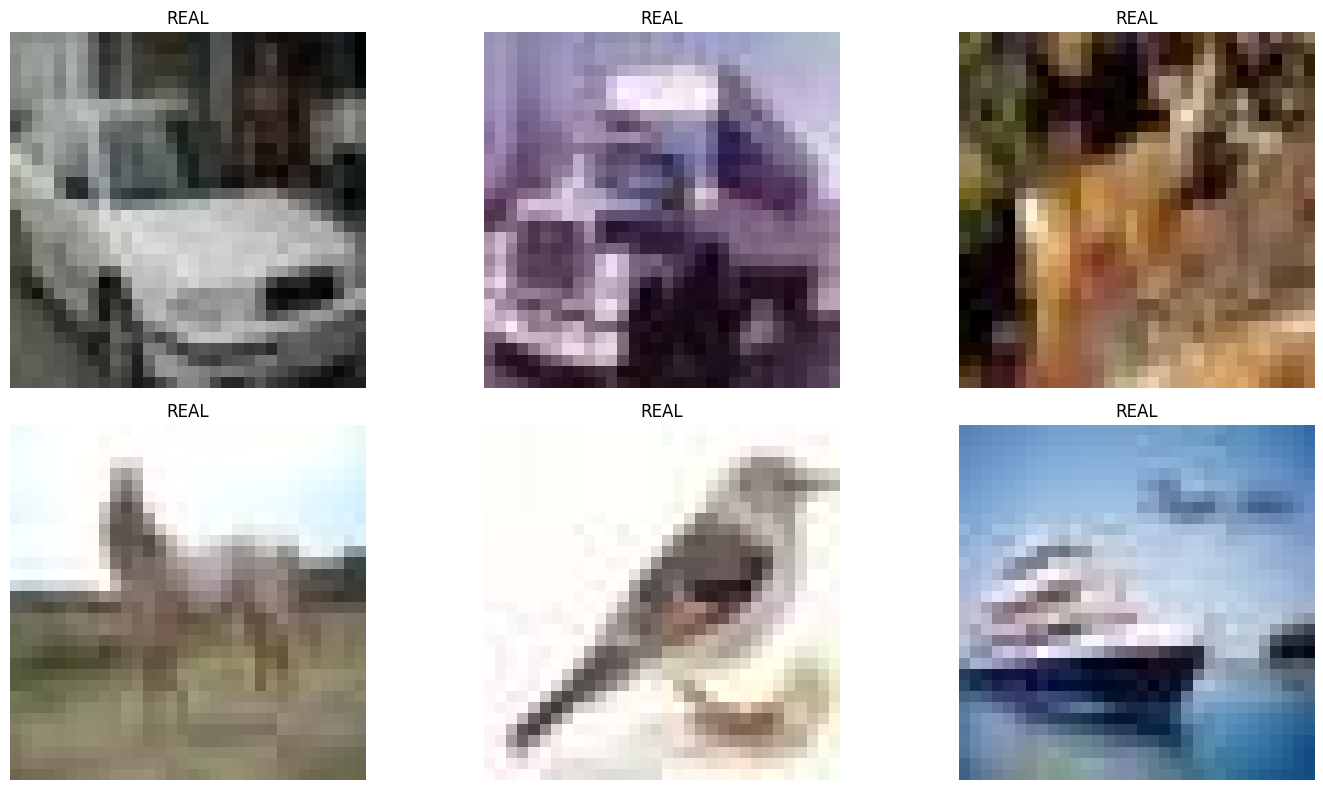

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_samples(folder, n=6):
    files = list(Path(folder).glob("*"))
    samples = random.sample(files, min(n, len(files)))

    plt.figure(figsize=(15, 8))
    for i, img_path in enumerate(samples, 1):
        img = Image.open(img_path).convert("RGB")
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(img_path.parent.name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(DATA_PATH / "train" / "FAKE", n=6)
show_samples(DATA_PATH / "train" / "REAL", n=6)

#CONFIG

In [ ]:
from dataclasses import dataclass, field
from pathlib import Path
import torch

In [ ]:
@dataclass
class Config:
    data_path: Path = Path("./DATASET")
    save_path: Path = Path("./checkpoints")

    # data
    img_size: int = 224
    batch_size: int = 64
    num_workers: int = 2
    val_ratio: float = 0.15
    random_seed: int = 42

    # model
    model_name: str = "resnet18"
    pretrained: bool = True
    freeze_backbone: bool = True
    num_classes: int = 2
    dropout: float = 0.3

    # training
    num_epochs: int = 15
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    label_smoothing: float = 0.1

    # device
    device: torch.device = field(default_factory=lambda: torch.device(
        "cuda" if torch.cuda.is_available() else
        "mps" if torch.backends.mps.is_available() else
        "cpu"
    ))

    use_amp: bool = True

    def __post_init__(self):
        self.save_path.mkdir(parents=True, exist_ok=True)

        if self.device.type != "cuda":
            self.use_amp = False

cfg = Config()
cfg.data_path = DATA_PATH
print(cfg)

Config(data_path=PosixPath('/content/CIFAKE-Real-and-AI-Generated-Synthetic-Images-main/DATASET'), save_path=PosixPath('checkpoints'), img_size=224, batch_size=64, num_workers=2, val_ratio=0.15, random_seed=42, model_name='resnet18', pretrained=True, freeze_backbone=True, num_classes=2, dropout=0.3, num_epochs=15, learning_rate=0.001, weight_decay=0.0001, label_smoothing=0.1, device=device(type='cuda'), use_amp=True)


In [ ]:
def set_seed(seed: int) -> None:
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

#Tranforms

In [ ]:
import torchvision.transforms as T
from typing import Dict

def build_transforms(img_size: int) -> dict[str, T.Compose]:

    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    train_transforms = T.Compose([
        T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        T.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    val_transforms = T.Compose([
        T.Resize(int(img_size * 1.14)),
        T.CenterCrop(img_size),
        T.ToTensor(),
        T.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    return {
        "train": train_transforms,
        "val": val_transforms
    }

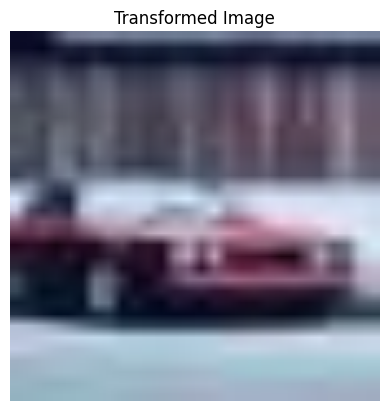

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
random.seed(42)

transforms = build_transforms(img_size=224)

# random image
img_path = random.choice(list((DATA_PATH / "train" / "FAKE").glob("*")))
img = Image.open(img_path).convert("RGB")


transformed = transforms["train"](img)

img_np = transformed.permute(1, 2, 0).numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

plt.imshow(img_np)
plt.title("Transformed Image")
plt.axis("off")
plt.show()

In [ ]:
transforms

{'train': Compose(
     RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
     RandomHorizontalFlip(p=0.5)
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ),
 'val': Compose(
     Resize(size=255, interpolation=bilinear, max_size=None, antialias=True)
     CenterCrop(size=(224, 224))
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 )}

#Datasets

In [ ]:
def build_datasets(
    data_path: Path,
    transforms: Dict[str, T.Compose],
    val_ratio: float = 0.15,
    random_seed: int = 42
) -> Tuple[Subset, Subset, ImageFolder]:

  data_root = Path(data_path)
  train_dir = data_root / "train"
  test_dir = data_root / "test"

  if not train_dir.exists():
    raise FileNotFoundError(f"Train directory not found: {train_dir}")
  if not test_dir.exists():
    raise FileNotFoundError(f"Test directory not found: {test_dir}")

  full_train_train_tfms = ImageFolder(root=str(train_dir), transform=transforms["train"])
  full_train_val_tfms = ImageFolder(root=str(train_dir), transform=transforms["val"])
  test_dataset = ImageFolder(root=str(test_dir), transform=transforms["val"])

  n_total= len(full_train_train_tfms)
  n_val = int(n_total * val_ratio)
  n_train = n_total - n_val

  if n_val == 0:
    raise ValueError("Validation split is empty. Increase val_ratio or use a larger dataset.")
  if n_train == 0:
    raise ValueError("Training split is empty. Decrease val_ratio.")

  generator = torch.Generator().manual_seed(random_seed)
  indices = torch.randperm(n_total, generator=generator).tolist()

  train_indices = indices[:n_train]
  val_indices = indices[n_train:]

  train_dataset = Subset(full_train_train_tfms, train_indices)
  val_dataset = Subset(full_train_val_tfms, val_indices)

  class_to_idx = full_train_train_tfms.class_to_idx

  print(f"\n{'=' * 50}")
  print(f"Class → Index mapping: {class_to_idx}")
  print(f"Train samples         : {len(train_dataset)}")
  print(f"Validation samples    : {len(val_dataset)}")
  print(f"Test samples          : {len(test_dataset)}")
  print(f"{'=' * 50}\n")

  return train_dataset, val_dataset, test_dataset

#DataLoaders

In [ ]:
def build_dataloaders(
    train_dataset: Subset,
    val_dataset: Subset,
    test_dataset: ImageFolder,
    batch_size: int,
    num_workers: int,
) -> Dict[str, DataLoader]:

  use_pin_memory = torch.cuda.is_available()

  train_loader = DataLoader(
      train_dataset,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=use_pin_memory,
      drop_last=True,
  )

  val_loader = DataLoader(
      val_dataset,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=use_pin_memory,
  )

  test_loader = DataLoader(
      test_dataset,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=use_pin_memory,
  )

  return {"train": train_loader,
            "val": val_loader,
            "test": test_loader
  }

In [ ]:
class AIDetectorModel(nn.Module):
    def __init__(
        self,
        backbone_name: str,
        pretrained: bool,
        num_classes: int,
        freeze_backbone: bool,
        dropout: float,
    ) -> None:
        super().__init__()


        weights = "IMAGENET1K_V1" if pretrained else None
        self.backbone = torchvision.models.get_model(backbone_name, weights=weights)


        in_features = self._get_backbone_out_features()
        self.backbone.fc = nn.Identity()

        if freeze_backbone:
            self._freeze_backbone()

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(p=dropout / 2),
            nn.Linear(256, num_classes)
        )

    def _get_backbone_out_features(self) -> int:
        fc = self.backbone.fc

        if isinstance(fc, nn.Linear):
            return fc.in_features

        raise AttributeError(
            f"Could not determine backbone output size. "
            f"backbone.fc is {type(fc)}. You may need to adapt this method."
        )

    def _freeze_backbone(self) -> None:
        for param in self.backbone.parameters():
            param.requires_grad = False

        print("[Model] Backbone frozen -> only head will be trained.")

    def unfreeze_backbone(self, layers: Optional[List[str]] = None) -> None:
        if layers is None:
            for param in self.backbone.parameters():
                param.requires_grad = True
            print("[Model] Full backbone unfrozen.")
        else:
            for name, param in self.backbone.named_parameters():
                if any(layer in name for layer in layers):
                    param.requires_grad = True
                    print(f"[Model] Unfrozen: {name}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        logits = self.head(features)
        return logits


def build_model(cfg: Config) -> AIDetectorModel:
    model = AIDetectorModel(
        backbone_name=cfg.model_name,
        pretrained=cfg.pretrained,
        num_classes=cfg.num_classes,
        freeze_backbone=cfg.freeze_backbone,
        dropout=cfg.dropout
    )

    model = model.to(cfg.device)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"[Model] Total params: {total_params:,}")
    print(f"[Model] Trainable params: {trainable_params:,}")
    print(f"[Model] Device: {cfg.device}")

    return model

#LOSS, OPTIMIZER, SCHEDULER

In [ ]:
def build_loss(cfg: Config) -> nn.Module:
  criterion = nn.CrossEntropyLoss(
      label_smoothing=cfg.label_smoothing
  )
  return criterion

def build_optimizer(
    model: nn.Module,
    cfg: Config
) -> optim.Optimizer:

  trainable_params = [
      param for param in model.parameters()
      if param.requires_grad
  ]

  optimizer = optim.AdamW(
      trainable_params,
      lr=cfg.learning_rate,
      weight_decay=cfg.weight_decay
  )

  return optimizer

def build_scheduler(
    optimizer: optim.Optimizer,
    cfg: Config
) -> optim.lr_scheduler.LRScheduler:

  scheduler = optim.lr_scheduler.CosineAnnealingLR(
      optimizer = optimizer,
      T_max = cfg.num_epochs,
      eta_min = 1e-6
  )

  return scheduler

#Train & Validation

In [ ]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scaler: GradScaler,
    device: torch.device,
    use_amp: bool,
) -> Tuple[float, float]:

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp and device.type == "cuda":
            with autocast():
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item() * labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
@torch.no_grad()
def validate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Tuple[float, float, float]:
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item() * labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / total
    accuracy = correct / total
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, accuracy, f1

#Evaluation

In [ ]:
@torch.no_grad()
def evaluate_on_test(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    class_names: List[str],
) -> None:
    model.eval()
    all_preds  = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)


        logits = model(images)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    print("\n" + "="*55)
    print("  TEST SET EVALUATION")
    print("="*55)
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        digits=4,
    ))

    # Confusion matrix plot.
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
    print("  Confusion matrix saved to confusion_matrix.png")


def plot_history(history: Dict[str, List[float]]) -> None:

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Training Curves — Experiment 1 Baseline", fontsize=13, fontweight="bold")

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
    axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train Acc", linewidth=2)
    axes[1].plot(epochs, history["val_acc"],   label="Val Acc",   linewidth=2, linestyle="--")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # F1
    axes[2].plot(epochs, history["val_f1"], label="Val F1 (macro)", linewidth=2, color="green")
    axes[2].axvline(
        x=np.argmax(history["val_f1"]) + 1,
        color="red", linestyle=":", linewidth=1.5, label="Best epoch"
    )
    axes[2].set_title("Validation F1 (macro)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("F1 Score")
    axes[2].legend()
    axes[2].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("  Training curves saved to training_curves.png")

#Main Training RUN

In [ ]:
def run_training(cfg: Config) -> nn.Module:
    print(f"\n{'=' * 55}")
    print("  EXPERIMENT 1 — BASELINE")
    print(f"  Model: {cfg.model_name} | Freeze backbone: {cfg.freeze_backbone}")
    print(f"  Device: {cfg.device} | AMP: {cfg.use_amp and cfg.device.type == 'cuda'}")
    print(f"{'=' * 55}\n")

    # Setup
    set_seed(cfg.random_seed)
    cfg.save_path.mkdir(parents=True, exist_ok=True)
    save_file = cfg.save_path / "best_model.pt"

    # Data
    transforms = build_transforms(cfg.img_size)

    train_ds, val_ds, test_ds = build_datasets(
        data_path=cfg.data_path,
        transforms=transforms,
        val_ratio=cfg.val_ratio,
        random_seed=cfg.random_seed,
    )

    loaders = build_dataloaders(
        train_dataset=train_ds,
        val_dataset=val_ds,
        test_dataset=test_ds,
        batch_size=cfg.batch_size,
        num_workers=cfg.num_workers,
    )

    class_names = test_ds.classes

    # Model setup
    model = build_model(cfg)
    criterion = build_loss(cfg)
    optimizer = build_optimizer(model, cfg)
    scheduler = build_scheduler(optimizer, cfg)

    scaler = GradScaler(
        enabled=cfg.use_amp and cfg.device.type == "cuda"
    )

    # History
    history: Dict[str, List[float]] = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
    }

    best_val_f1 = -1.0
    best_epoch = -1

    # Training loop
    for epoch in range(1, cfg.num_epochs + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=loaders["train"],
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=cfg.device,
            use_amp=cfg.use_amp,
        )

        val_loss, val_acc, val_f1 = validate_one_epoch(
            model=model,
            loader=loaders["val"],
            criterion=criterion,
            device=cfg.device,
        )

        scheduler.step()

        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch [{epoch:>2}/{cfg.num_epochs}] "
            f"| Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
            f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} "
            f"| LR: {current_lr:.2e} "
            f"| {elapsed:.1f}s"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_f1": best_val_f1,
                },
                save_file,
            )

            print(f"  ✓ New best model saved (Val F1: {best_val_f1:.4f})")

    print(f"\n  Training complete. Best Val F1: {best_val_f1:.4f} at epoch {best_epoch}.")
    print(f"  Checkpoint saved to: {save_file}")

    checkpoint = torch.load(save_file, map_location=cfg.device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"  Loaded best model from epoch {checkpoint['epoch']}.")

    evaluate_on_test(
        model=model,
        loader=loaders["test"],
        device=cfg.device,
        class_names=class_names,
    )

    plot_history(history)

    return model


  EXPERIMENT 1 — BASELINE
  Model: resnet18 | Freeze backbone: True
  Device: cuda | AMP: True


Class → Index mapping: {'FAKE': 0, 'REAL': 1}
Train samples         : 85000
Validation samples    : 15000
Test samples          : 20000

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


[Model] Backbone frozen -> only head will be trained.
[Model] Total params: 11,309,890
[Model] Trainable params: 133,378
[Model] Device: cuda


/tmp/ipykernel_492/3880211698.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(
/tmp/ipykernel_492/2917382760.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [ 1/15] | Train Loss: 0.4213 Acc: 0.8580 | Val Loss: 0.3697 Acc: 0.8961 F1: 0.8961 | LR: 9.89e-04 | 210.8s
  ✓ New best model saved (Val F1: 0.8961)


...

Epoch [13/15] | Train Loss: 0.3608 Acc: 0.9046 | Val Loss: 0.3330 Acc: 0.9258 F1: 0.9258 | LR: 4.42e-05 | 217.5s
  ✓ New best model saved (Val F1: 0.9258)


/tmp/ipykernel_492/2917382760.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [14/15] | Train Loss: 0.3595 Acc: 0.9043 | Val Loss: 0.3341 Acc: 0.9246 F1: 0.9246 | LR: 1.19e-05 | 206.8s


/tmp/ipykernel_492/2917382760.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [15/15] | Train Loss: 0.3593 Acc: 0.9045 | Val Loss: 0.3328 Acc: 0.9259 F1: 0.9259 | LR: 1.00e-06 | 207.9s
  ✓ New best model saved (Val F1: 0.9259)

  Training complete. Best Val F1: 0.9259 at epoch 15.
  Checkpoint saved to: checkpoints/best_model.pt
  Loaded best model from epoch 15.

  TEST SET EVALUATION
              precision    recall  f1-score   support

        FAKE     0.9275    0.9230    0.9252     10000
        REAL     0.9234    0.9278    0.9256     10000

    accuracy                         0.9254     20000
   macro avg     0.9254    0.9254    0.9254     20000
weighted avg     0.9254    0.9254    0.9254     20000



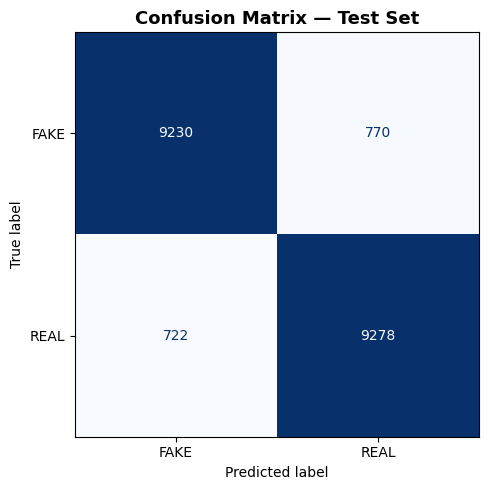

  Confusion matrix saved to confusion_matrix.png


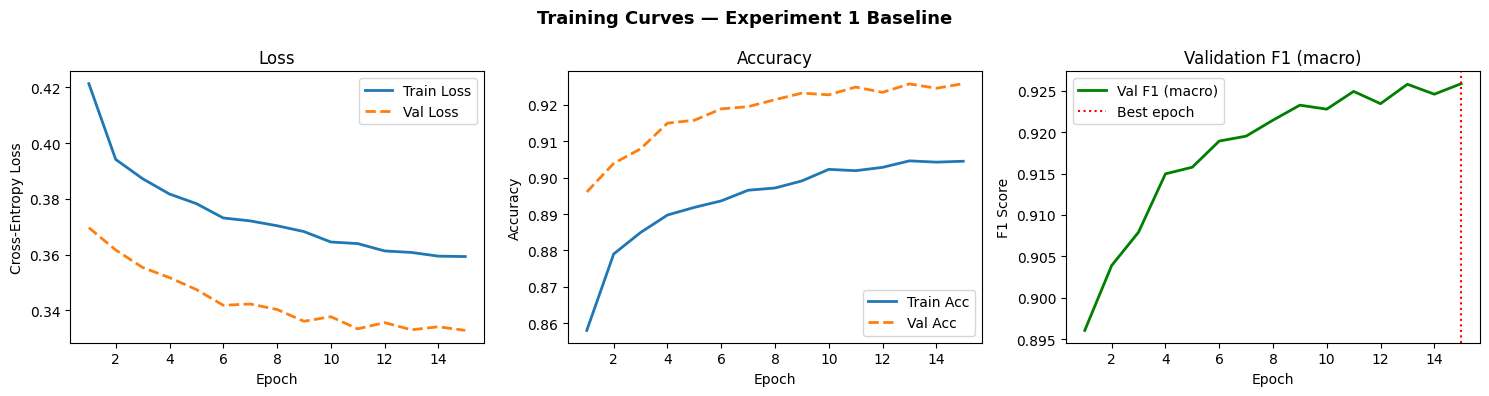

  Training curves saved to training_curves.png


In [ ]:
if __name__ == "__main__":
    cfg = Config()
    cfg.data_path = DATA_PATH
    trained_model = run_training(cfg)